In [1]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import f1_score, roc_auc_score

LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
PROC_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
device = "mps" if torch.backends.mps.is_available() else "cpu"

test = pd.read_csv(PROC_DIR / "test_official_filtered.csv")
y_test = test[LABEL_COLS].values
print("Test rows:", len(test))


Test rows: 63978


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def predict_probs(model_dir, texts, batch_size=64, max_length=128):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    model.eval()

    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = tokenizer(list(batch), truncation=True, max_length=max_length,
                             padding=True, return_tensors="pt").to(device)
            logits = model(**enc).logits
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)


def evaluate(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    macro_auc = roc_auc_score(y_true, y_prob, average="macro")
    per_label_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    per_label_auc = roc_auc_score(y_true, y_prob, average=None)
    return macro_f1, macro_auc, per_label_f1, per_label_auc


In [3]:
bert_probs = predict_probs(str(MODELS_DIR / "bert"), test["comment_text"].tolist())
bert_f1, bert_auc, bert_per_f1, bert_per_auc = evaluate(y_test, bert_probs)
print(f"BERT macro F1: {bert_f1:.3f}  macro AUC: {bert_auc:.3f}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT macro F1: 0.555  macro AUC: 0.980


In [4]:
roberta_probs = predict_probs(str(MODELS_DIR / "roberta"), test["comment_text"].tolist())
roberta_f1, roberta_auc, roberta_per_f1, roberta_per_auc = evaluate(y_test, roberta_probs)
print(f"RoBERTa macro F1: {roberta_f1:.3f}  macro AUC: {roberta_auc:.3f}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa macro F1: 0.545  macro AUC: 0.981


In [5]:
metrics_path = Path("../reports/metrics.json")
all_metrics = json.loads(metrics_path.read_text())

all_metrics["bert"] = {
    "macro_f1": float(bert_f1), "macro_auc": float(bert_auc),
    "per_label_f1": dict(zip(LABEL_COLS, bert_per_f1.tolist())),
    "per_label_auc": dict(zip(LABEL_COLS, bert_per_auc.tolist())),
}
all_metrics["roberta"] = {
    "macro_f1": float(roberta_f1), "macro_auc": float(roberta_auc),
    "per_label_f1": dict(zip(LABEL_COLS, roberta_per_f1.tolist())),
    "per_label_auc": dict(zip(LABEL_COLS, roberta_per_auc.tolist())),
}
metrics_path.write_text(json.dumps(all_metrics, indent=2))



np.save(PROC_DIR / "bert_test_probs.npy", bert_probs)
np.save(PROC_DIR / "roberta_test_probs.npy", roberta_probs)

MODEL_KEYS = ["baseline_tfidf_logreg", "bert", "roberta"]
comparison = pd.DataFrame({
    model: {"macro_f1": all_metrics[model]["macro_f1"], "macro_auc": all_metrics[model]["macro_auc"]}
    for model in MODEL_KEYS if model in all_metrics
}).T
comparison


,macro_f1,macro_auc
baseline_tfidf_logreg,0.446468,0.968309
bert,0.555100,0.980462
roberta,0.544507,0.980563


In [6]:
baseline_f1 = all_metrics["baseline_tfidf_logreg"]["macro_f1"]
for name in ["bert", "roberta"]:
    gap = (all_metrics[name]["macro_f1"] - baseline_f1) / baseline_f1 * 100
    print(f"{name}: {gap:+.1f}% macro-F1 vs. TF-IDF/LogReg baseline")


bert: +24.3% macro-F1 vs. TF-IDF/LogReg baseline
roberta: +22.0% macro-F1 vs. TF-IDF/LogReg baseline


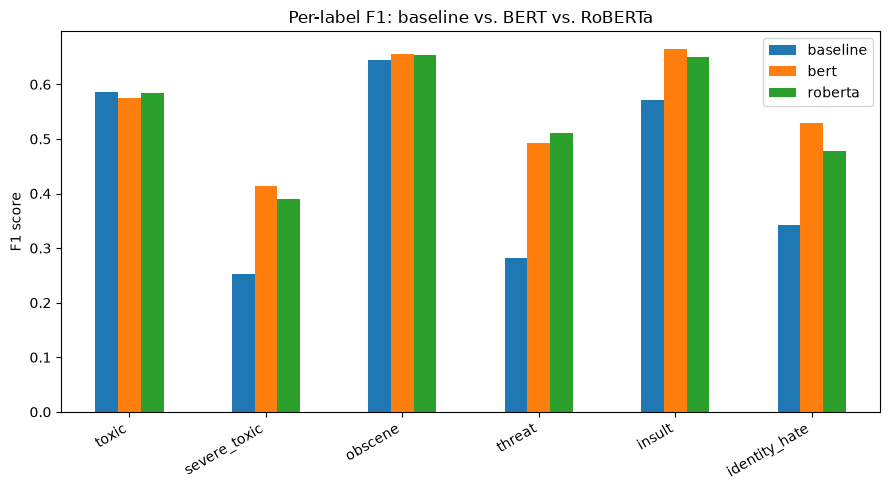

In [7]:
per_label_df = pd.DataFrame({
    "baseline": all_metrics["baseline_tfidf_logreg"]["per_label_f1"],
    "bert": all_metrics["bert"]["per_label_f1"],
    "roberta": all_metrics["roberta"]["per_label_f1"],
})

ax = per_label_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("F1 score")
ax.set_title("Per-label F1: baseline vs. BERT vs. RoBERTa")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/per_label_f1_comparison.png", dpi=150)
plt.show()


In [8]:
best_model_name = "bert" if bert_f1 >= roberta_f1 else "roberta"
best_probs = bert_probs if best_model_name == "bert" else roberta_probs
print("Best model (used for thresholds + demo app):", best_model_name)

val_df = pd.read_csv(PROC_DIR / "val_subsample.csv")
y_val = val_df[LABEL_COLS].values

best_val_probs = predict_probs(str(MODELS_DIR / best_model_name), val_df["comment_text"].tolist())

thresholds = np.arange(0.05, 0.55, 0.05)
best_thresholds = {}
for i, label in enumerate(LABEL_COLS):
    scores = [f1_score(y_val[:, i], (best_val_probs[:, i] >= t).astype(int), zero_division=0)
              for t in thresholds]
    best_thresholds[label] = float(thresholds[np.argmax(scores)])

print("Best per-label thresholds (chosen on validation set):")
best_thresholds


Best model (used for thresholds + demo app): bert


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best per-label thresholds (chosen on validation set):


{'toxic': 0.5,
 'severe_toxic': 0.2,
 'obscene': 0.15000000000000002,
 'threat': 0.5,
 'insult': 0.35000000000000003,
 'identity_hate': 0.15000000000000002}

In [9]:

tuned_preds = np.zeros_like(y_test)
for i, label in enumerate(LABEL_COLS):
    tuned_preds[:, i] = (best_probs[:, i] >= best_thresholds[label]).astype(int)

tuned_f1 = f1_score(y_test, tuned_preds, average="macro", zero_division=0)
tuned_per_f1 = f1_score(y_test, tuned_preds, average=None, zero_division=0)

best_f1 = bert_f1 if best_model_name == "bert" else roberta_f1
print(f"{best_model_name} macro F1 with threshold=0.5 for every label: {best_f1:.3f}")
print(f"{best_model_name} macro F1 with per-label tuned thresholds:    {tuned_f1:.3f}")
pd.DataFrame({"tuned_threshold": best_thresholds, "f1_at_tuned_threshold": dict(zip(LABEL_COLS, tuned_per_f1))})


bert macro F1 with threshold=0.5 for every label: 0.555
bert macro F1 with per-label tuned thresholds:    0.511


,tuned_threshold,f1_at_tuned_threshold
toxic,0.50,0.575473
severe_toxic,0.20,0.315686
obscene,0.15,0.589388
threat,0.50,0.492401
insult,0.35,0.640388
identity_hate,0.15,0.453578


In [10]:


all_metrics["best_model"] = best_model_name
all_metrics["tuned_thresholds"] = best_thresholds
metrics_path.write_text(json.dumps(all_metrics, indent=2))
print("Saved best_model + tuned_thresholds to", metrics_path)


Saved best_model + tuned_thresholds to ../reports/metrics.json
